# CAVE/SegCLR presynaptic-axon database diagnostics

Reproduce the three distance distributions generated while building the `K=10` presynaptic-axon database. Distances are loaded directly from the per-cell records, so this notebook is also an independent check of the finalized metadata.

The red line is the 2 µm acceptance cutoff. The percentage in each panel is calculated from the complete underlying distribution, including values beyond the displayed 99.5th-percentile range.

In [ ]:
# Avoid slow transparent-huge-page allocation on this cluster node.
# The environment setting covers fresh imports; the runtime setting also
# covers NumPy already imported by the notebook kernel.
import os
os.environ['NUMPY_MADVISE_HUGEPAGE'] = '0'
import numpy as np
_numpy_core = getattr(np, '_core', None)
if _numpy_core is None:
    _numpy_core = np.core
_set_hugepage = getattr(_numpy_core.multiarray, '_set_madvise_hugepage', None)
if _set_hugepage is not None:
    _set_hugepage(False)

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

DB = Path('/orcd/scratch/orcd/013/jcbliao/presynaptic_axons/k10')
CELL_DIR = DB / 'cells'
FIGURE_DIR = DB / 'figures'
CUTOFF_NM = 2_000.0
SAVE = False  # Set True to overwrite the database's PNG and PDF exports.

metadata = json.loads((DB / 'metadata.json').read_text())
print(f"{metadata['n_cells']:,} cells; {metadata['n_presynaptic']:,} presynaptic points")
print(f"K={metadata['k_observed']}; LPE width={metadata['lpe_dim']}")

## Load the complete distributions

NumPy reads only the requested members from each compressed per-cell record. The large graph and LPE arrays are not materialized here.

In [ ]:
def load_distance_arrays(cell_dir=CELL_DIR):
    embedding_to_new = []
    presynaptic_to_cave = []
    presynaptic_to_new = []
    excluded = set(map(int, metadata.get('discarded_without_current_embeddings_root_ids', [])))
    files = [p for p in sorted(cell_dir.glob('*.npz')) if int(p.stem) not in excluded]
    for path in tqdm(files, desc='loading cell records', unit='cell'):
        with np.load(path) as cell:
            embedding_to_new.append(cell['embedding_to_new_distance_nm'])
            presynaptic_to_cave.append(cell['cave_nearest_observed_distance_nm'])
            presynaptic_to_new.append(cell['new_nearest_observed_distance_nm'])
    return {
        'embedding_to_new': np.concatenate(embedding_to_new),
        'presynaptic_to_cave': np.concatenate(presynaptic_to_cave),
        'presynaptic_to_new': np.concatenate(presynaptic_to_new),
    }

distances_nm = load_distance_arrays()
{name: values.shape for name, values in distances_nm.items()}

## Plotting function

The histogram view is capped at the 99.5th percentile (and at most 20 µm) so the accepted-distance region remains legible. Rejection fractions always use every finite value.

In [ ]:
def plot_cutoff_distribution(
    values_nm, *, title, rejected_label, filename=None, cutoff_nm=CUTOFF_NM
):
    values_um = np.asarray(values_nm, dtype=np.float64) / 1_000.0
    values_um = values_um[np.isfinite(values_um)]
    cutoff_um = cutoff_nm / 1_000.0
    rejected = np.mean(values_um > cutoff_um)
    xmax = max(cutoff_um * 1.1, min(np.percentile(values_um, 99.5), 20.0))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(values_um, bins=np.linspace(0, xmax, 101), color='#3978b5', alpha=0.85)
    ax.axvline(cutoff_um, color='#b22222', linewidth=2, label=f'{cutoff_um:g} µm cutoff')
    ax.set(title=title, xlabel='nearest distance (µm)', ylabel='count')
    ax.text(
        0.98, 0.95, f'{rejected_label}: {rejected:.2%}',
        transform=ax.transAxes, ha='right', va='top',
        bbox={'facecolor': 'white', 'alpha': 0.9},
    )
    ax.legend()
    fig.tight_layout()
    if SAVE and filename is not None:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURE_DIR / f'{filename}.png', dpi=180)
        fig.savefig(FIGURE_DIR / f'{filename}.pdf')
    plt.show()
    return rejected

## 1. SegCLR CAVE node → new-skeleton node

Each SegCLR embedding starts on its observed CAVE node after the 5 µm root cut. It is transferred to the nearest surviving new-skeleton node only when this distance is at most 2 µm.

In [ ]:
embedding_rejected = plot_cutoff_distribution(
    distances_nm['embedding_to_new'],
    title='SegCLR CAVE node → nearest new-skeleton node',
    rejected_label='embeddings discarded',
    filename='embedding_to_new_skeleton_distance',
)

## 2. Presynaptic point → CAVE SegCLR node

A presynaptic point is accepted only when its nearest surviving SegCLR-observed CAVE node lies within 2 µm.

In [ ]:
cave_presynaptic_rejected = plot_cutoff_distribution(
    distances_nm['presynaptic_to_cave'],
    title='Presynaptic point → nearest CAVE SegCLR node',
    rejected_label='presynaptic points beyond cutoff',
    filename='presynaptic_to_cave_segclr_distance',
)

## 3. Presynaptic point → mapped new-skeleton SegCLR node

This includes both spatial joins: CAVE SegCLR node to new skeleton, followed by presynaptic point to the nearest new-skeleton node that retained an embedding.

In [ ]:
new_presynaptic_rejected = plot_cutoff_distribution(
    distances_nm['presynaptic_to_new'],
    title='Presynaptic point → nearest mapped new-skeleton SegCLR node',
    rejected_label='presynaptic points beyond cutoff',
    filename='presynaptic_to_new_segclr_distance',
)

## Numerical cross-check against `metadata.json`

In [ ]:
checks = {
    'embedding mapping': (embedding_rejected, metadata['embedding_mapping_discard_fraction']),
    'CAVE presynaptic': (cave_presynaptic_rejected, metadata['cave_presynaptic_cutoff_discard_fraction']),
    'new presynaptic': (new_presynaptic_rejected, metadata['new_presynaptic_cutoff_discard_fraction']),
}
for name, (notebook_value, metadata_value) in checks.items():
    assert np.isclose(notebook_value, metadata_value), (name, notebook_value, metadata_value)
    print(f'{name:20s}: {notebook_value:.4%}')

## 4. Mean presynaptic-to-CAVE SegCLR distance per cell

One dot per cell, colored by `segclr_db` cell type. **X:** random horizontal jitter for visibility, with no quantitative meaning (fixed seed for reproducibility). **Y:** mean distance over all presynaptic points, including those beyond 2 µm. Distances use the same `presynaptic_axons/k10/cells` records as the plots above.

The first cell loads the saved per-cell summary (2,209 rows), avoiding repeated reads of all NPZ records and the shared label store. Set `REFRESH_CELL_SUMMARY = True` to rebuild after source data or labels change. The second cell only plots, so appearance changes do not reload the data. The NumPy huge-page workaround is also applied in this section for independent execution.


In [1]:
from pathlib import Path
from time import perf_counter
import os
import json

# Apply here too, so this section can run without the initial setup cell.
os.environ['NUMPY_MADVISE_HUGEPAGE'] = '0'
import numpy as np
_numpy_core = getattr(np, '_core', None)
if _numpy_core is None:
    _numpy_core = np.core
_set_hugepage = getattr(_numpy_core.multiarray, '_set_madvise_hugepage', None)
if _set_hugepage is not None:
    _set_hugepage(False)
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

mean_repo = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'analysis/presynaptic/cave_skeletons/presynaptic_axon_database_figures.ipynb').is_file())
mean_out = mean_repo / 'analysis/presynaptic/cave_skeletons'
mean_cache = mean_out / 'presynaptic_mean_cave_distance_per_cell.csv'
REFRESH_CELL_SUMMARY = False  # Set True after changing the source database or labels.
mean_started = perf_counter()

if REFRESH_CELL_SUMMARY or not mean_cache.is_file():
    import lance
    from tqdm.auto import tqdm
    print('Rebuilding per-cell summary from k10 records...', flush=True)
    mean_db = Path('/orcd/scratch/orcd/013/jcbliao/presynaptic_axons/k10')
    mean_metadata = json.loads((mean_db / 'metadata.json').read_text())
    mean_paths = sorted((mean_db / 'cells').glob('*.npz'))
    assert len(mean_paths) == mean_metadata['n_cells']
    mean_rows = []
    for cell_path in tqdm(mean_paths, desc='Mean CAVE distance per cell', unit='cell'):
        with np.load(cell_path, allow_pickle=False) as cell:
            values_nm = cell['cave_nearest_observed_distance_nm'].astype(np.float64)
            root_id = int(cell['root_id'].item())
        assert root_id == int(cell_path.stem)
        assert len(values_nm) and np.isfinite(values_nm).all(), cell_path
        mean_rows.append({
            'root_id': root_id,
            'n_presynaptic_points': len(values_nm),
            'mean_distance_um': values_nm.mean() / 1000.0,
            'n_presynaptic_points_over_2um': int(np.count_nonzero(values_nm > 2000.0)),
            'fraction_presynaptic_points_over_2um': float(np.mean(values_nm > 2000.0)),
        })
    cell_mean_distances = pd.DataFrame(mean_rows)
    cell_mean_distances['root_id'] = cell_mean_distances['root_id'].astype('uint64')
    assert cell_mean_distances['root_id'].is_unique
    assert cell_mean_distances['n_presynaptic_points'].sum() == mean_metadata['n_presynaptic']
    
    print(f'Distances loaded in {perf_counter() - mean_started:.2f}s; reading segclr_db labels...', flush=True)
    # Read the label table directly so the older vendored store API is not used.
    label_path = '/orcd/compute/sdorkenw/001/segclr-db/microns/dims/cell_labels.lance'
    mean_labels = lance.dataset(label_path).to_table(
        columns=['root_id', 'label_set', 'label', 'mat_version']
    ).to_pandas()
    mean_labels = mean_labels.loc[
        mean_labels['label_set'].eq('cell_type')
        & mean_labels['mat_version'].eq(mean_metadata['materialization_version']),
        ['root_id', 'label'],
    ].drop_duplicates().rename(columns={'label': 'cell_type'})
    assert mean_labels['root_id'].is_unique, 'Conflicting cell-type labels'
    cell_mean_distances = cell_mean_distances.merge(mean_labels, on='root_id', how='left', validate='one_to_one')
    assert cell_mean_distances['cell_type'].notna().all(), 'Missing cell-type labels'
    cell_mean_distances = cell_mean_distances.sort_values(
        ['mean_distance_um', 'root_id'], ignore_index=True
    )
    cell_mean_distances.insert(0, 'mean_distance_rank', np.arange(1, len(cell_mean_distances) + 1))
    
    cell_mean_distances.to_csv(mean_cache, index=False)
else:
    cell_mean_distances = pd.read_csv(mean_cache, dtype={'root_id': 'uint64'})

assert cell_mean_distances['root_id'].is_unique
assert cell_mean_distances['cell_type'].notna().all()
assert np.isfinite(cell_mean_distances['mean_distance_um']).all()
assert (cell_mean_distances['n_presynaptic_points'] > 0).all()
assert np.allclose(
    cell_mean_distances['fraction_presynaptic_points_over_2um'],
    cell_mean_distances['n_presynaptic_points_over_2um'] / cell_mean_distances['n_presynaptic_points'],
)
print(f'Loaded {len(cell_mean_distances):,} cells in {perf_counter() - mean_started:.2f}s')


Loaded 2,209 cells in 0.01s


Plotted 2,209 cells in 0.29s


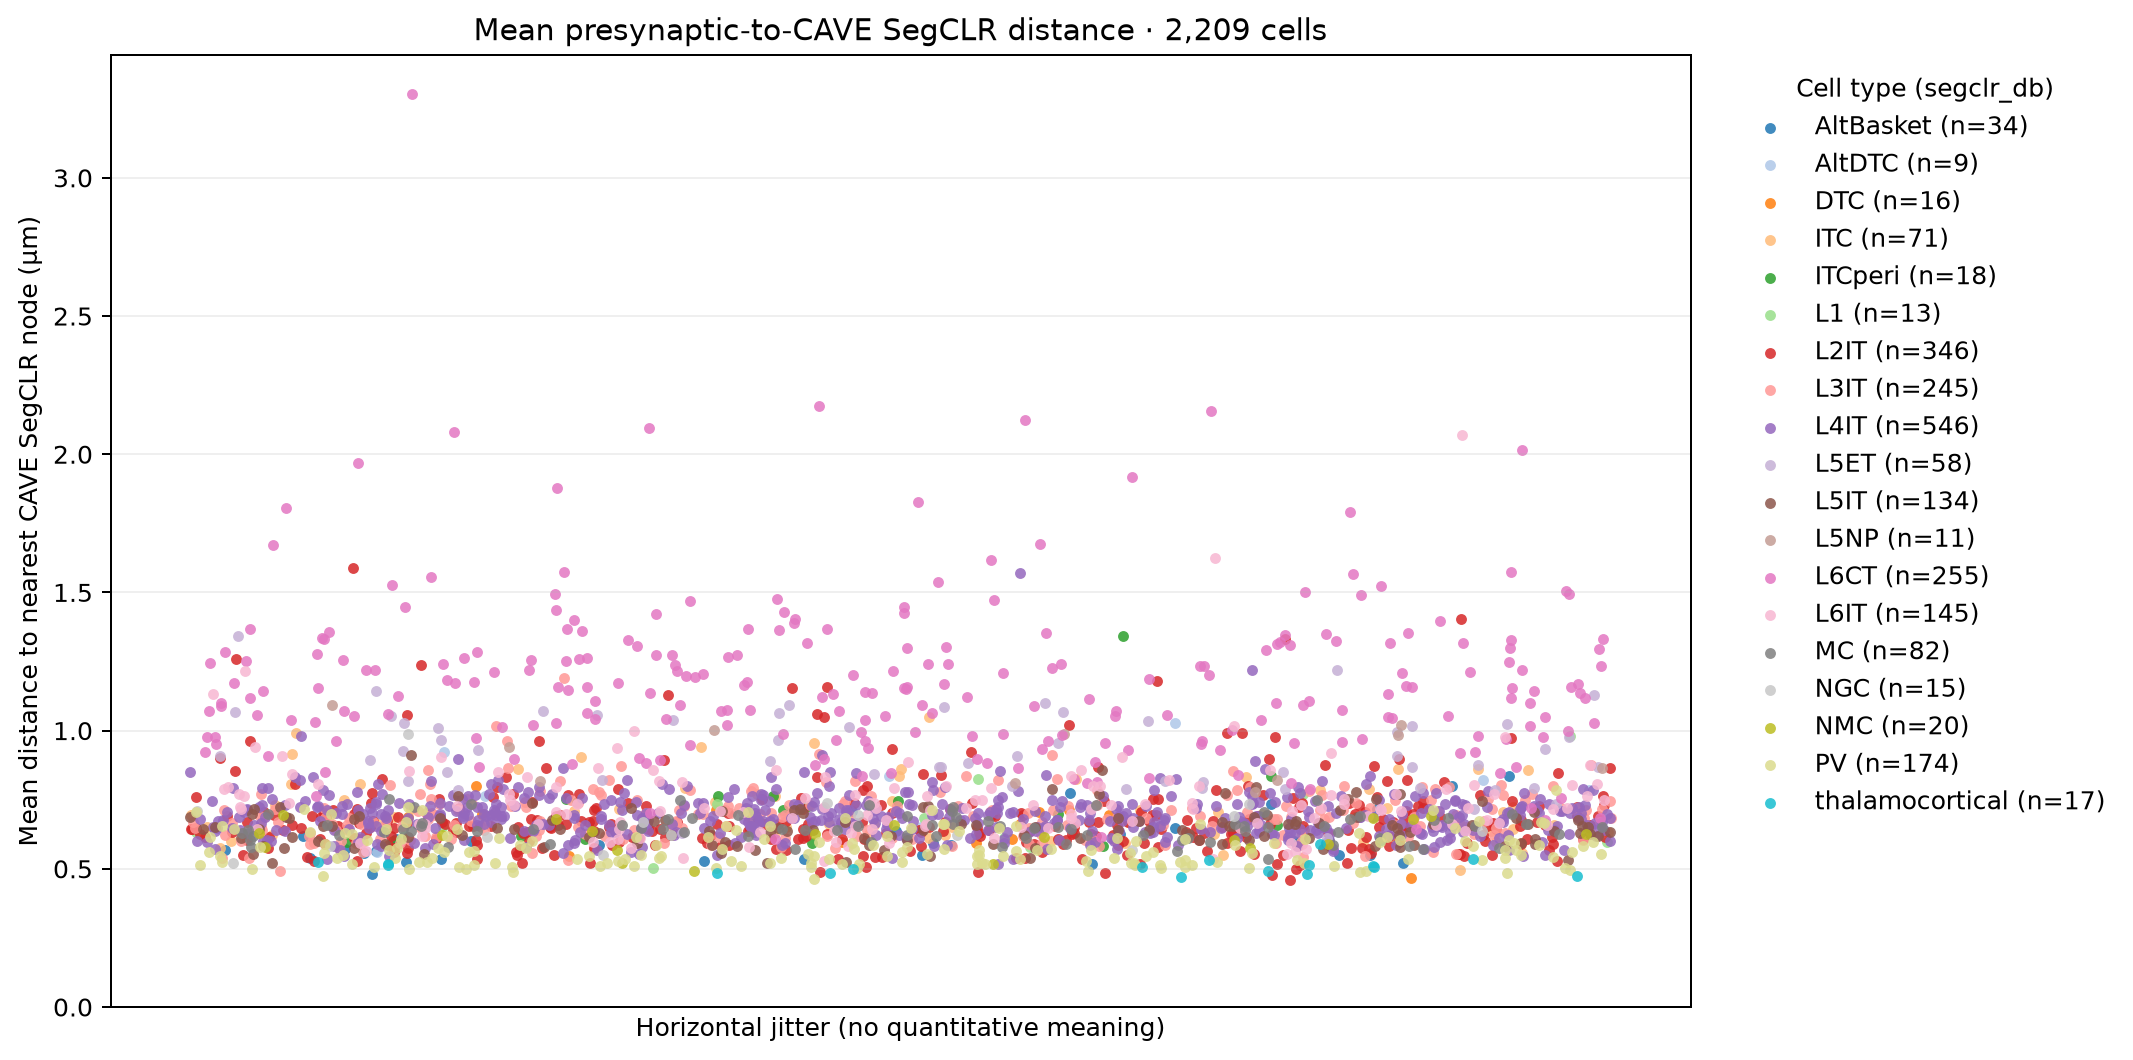

In [2]:
plot_started = perf_counter()
# Fixed seed keeps each cell at the same horizontal position on reruns.
jitter_rng = np.random.default_rng(42)
cell_mean_distances['horizontal_jitter'] = jitter_rng.uniform(-0.45, 0.45, len(cell_mean_distances))
cell_types = sorted(cell_mean_distances['cell_type'].unique())
colors = plt.get_cmap('tab20', max(20, len(cell_types)))
fig_cell_means, ax_cell_means = plt.subplots(figsize=(12, 6))
for index, cell_type in enumerate(cell_types):
    group = cell_mean_distances.loc[cell_mean_distances['cell_type'].eq(cell_type)]
    ax_cell_means.scatter(
        group['horizontal_jitter'], group['mean_distance_um'],
        s=19, alpha=0.85, color=colors(index), linewidths=0,
        label=f'{cell_type} (n={len(group):,})', rasterized=True,
    )
ax_cell_means.set(
    xlabel='Horizontal jitter (no quantitative meaning)',
    ylabel='Mean distance to nearest CAVE SegCLR node (µm)',
    title=f'Mean presynaptic-to-CAVE SegCLR distance · {len(cell_mean_distances):,} cells',
    xlim=(-0.5, 0.5), ylim=(0, None),
)
ax_cell_means.set_xticks([])
ax_cell_means.grid(axis='y', alpha=0.2)
ax_cell_means.legend(title='Cell type (segclr_db)', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig_cell_means.tight_layout()

fig_cell_means.savefig(mean_out / 'presynaptic_mean_cave_distance_per_cell.png', dpi=180, bbox_inches='tight')
print(f'Plotted {len(cell_mean_distances):,} cells in {perf_counter() - plot_started:.2f}s')
plt.show()
